# F_S2 — CNN Scatter Plot Classifier

Train a CNN on 128×128 binary scatter images → 4 classes (linear, quadratic, sigmoid, other).

- StratifiedGroupKFold(5) with group=config_id
- Balanced class weights
- Full evaluation: confusion matrix, accuracy vs SNR, per-class metrics

In [1]:
from __future__ import annotations

import json
import math
import time
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    balanced_accuracy_score, f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

DATA_DIR = Path('output/S1')
OUTPUT_DIR = Path('output/S2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f'Device: {DEVICE}')

CLASS_NAMES = ['linear', 'quadratic', 'sigmoid', 'other']
N_CLASSES = len(CLASS_NAMES)
CLASS_COLORS = {'linear': '#1976D2', 'quadratic': '#E64A19',
                'sigmoid': '#388E3C', 'other': '#7B1FA2'}

Device: mps


In [2]:
cases = pd.read_csv(DATA_DIR / 'cases.csv')
images = np.load(DATA_DIR / 'images.npz')['images']

cases['snr_float'] = cases['snr'].apply(lambda v: math.inf if str(v) == 'inf' else float(v))
cases['label'] = cases['class_name'].map({n: i for i, n in enumerate(CLASS_NAMES)})

print(f'Cases: {len(cases):,}')
print(f'Images: {images.shape}')
print(f'\nClass distribution:')
print(cases['class_name'].value_counts().reindex(CLASS_NAMES))

Cases: 28,050
Images: (28050, 128, 128)

Class distribution:
class_name
linear       6120
quadratic    9180
sigmoid      6120
other        6630
Name: count, dtype: int64


## PyTorch Dataset

In [3]:
class ScatterDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.from_numpy(images).float().unsqueeze(1)  # (N, 1, H, W)
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

## CNN Architecture

4-layer ConvNet: Conv→BN→ReLU→MaxPool, then AdaptiveAvgPool→FC→4

In [4]:
class ScatterCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # 1x1
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model_tmp = ScatterCNN()
n_params = sum(p.numel() for p in model_tmp.parameters())
print(f'Model parameters: {n_params:,}')
del model_tmp

Model parameters: 389,828


## Training with StratifiedGroupKFold

In [5]:
N_FOLDS = 5
N_EPOCHS = 20
BATCH_SIZE = 128
LR = 1e-3

labels_all = cases['label'].values
groups_all = cases['config_id'].values

# Balanced class weights
class_counts = np.bincount(labels_all, minlength=N_CLASSES)
class_weights = (1.0 / class_counts) * len(labels_all) / N_CLASSES
class_weights_t = torch.FloatTensor(class_weights).to(DEVICE)
print('Class weights:', {CLASS_NAMES[i]: f'{class_weights[i]:.3f}' for i in range(N_CLASSES)})

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_results = []
all_preds = np.full(len(cases), -1, dtype=int)
all_probs = np.zeros((len(cases), N_CLASSES), dtype=np.float32)
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(np.arange(len(cases)), labels_all, groups_all)):
    print(f'\n{"="*60}')
    print(f'Fold {fold + 1}/{N_FOLDS}')
    print(f'  Train: {len(train_idx):,}  Val: {len(val_idx):,}')

    # Check no config leakage
    train_groups = set(groups_all[train_idx])
    val_groups = set(groups_all[val_idx])
    assert len(train_groups & val_groups) == 0, 'Group leakage!'

    train_ds = ScatterDataset(images[train_idx], labels_all[train_idx])
    val_ds = ScatterDataset(images[val_idx], labels_all[val_idx])
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = ScatterCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(N_EPOCHS):
        # Train
        model.train()
        train_loss = 0.0
        for X, y in train_dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y)
        train_loss /= len(train_idx)

        # Validate
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                val_loss += criterion(out, y).item() * len(y)
                correct += (out.argmax(1) == y).sum().item()
        val_loss /= len(val_idx)
        val_acc = correct / len(val_idx)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'    Ep {epoch+1:>2} — train_loss={train_loss:.4f}  '
                  f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    fold_histories.append(history)

    # Collect predictions on validation set
    model.eval()
    with torch.no_grad():
        probs_list = []
        for X, _ in val_dl:
            X = X.to(DEVICE)
            out = model(X)
            probs_list.append(torch.softmax(out, dim=1).cpu().numpy())
        probs = np.concatenate(probs_list)
        preds = probs.argmax(axis=1)
        all_preds[val_idx] = preds
        all_probs[val_idx] = probs

    fold_acc = accuracy_score(labels_all[val_idx], preds)
    fold_bal = balanced_accuracy_score(labels_all[val_idx], preds)
    fold_f1 = f1_score(labels_all[val_idx], preds, average='macro')
    cv_results.append({'fold': fold + 1, 'acc': fold_acc, 'bal_acc': fold_bal, 'f1': fold_f1})
    print(f'  ▸ Fold {fold+1} — acc={fold_acc:.4f}  bal_acc={fold_bal:.4f}  f1={fold_f1:.4f}')

# Summary
cv_df = pd.DataFrame(cv_results)
print(f'\n{"="*60}')
print(f'CV Results (mean ± std):')
for col in ['acc', 'bal_acc', 'f1']:
    print(f'  {col:>8}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}')
cv_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)

Class weights: {'linear': '1.146', 'quadratic': '0.764', 'sigmoid': '1.146', 'other': '1.058'}

Fold 1/5
  Train: 22,440  Val: 5,610
    Ep  1 — train_loss=1.0590  val_loss=0.9976  val_acc=0.5321
    Ep  5 — train_loss=0.7022  val_loss=0.8777  val_acc=0.5857
    Ep 10 — train_loss=0.5915  val_loss=0.8780  val_acc=0.6086
    Ep 15 — train_loss=0.5160  val_loss=0.7680  val_acc=0.6572
    Ep 20 — train_loss=0.4624  val_loss=0.7167  val_acc=0.6643
  ▸ Fold 1 — acc=0.6643  bal_acc=0.6732  f1=0.6664

Fold 2/5
  Train: 22,440  Val: 5,610
    Ep  1 — train_loss=1.0594  val_loss=1.0352  val_acc=0.4624
    Ep  5 — train_loss=0.7035  val_loss=1.2843  val_acc=0.4829
    Ep 10 — train_loss=0.6080  val_loss=0.6736  val_acc=0.6859
    Ep 15 — train_loss=0.5148  val_loss=0.7232  val_acc=0.6684
    Ep 20 — train_loss=0.4599  val_loss=0.7123  val_acc=0.6706
  ▸ Fold 2 — acc=0.6706  bal_acc=0.7039  f1=0.6713

Fold 3/5
  Train: 22,440  Val: 5,610
    Ep  1 — train_loss=1.0646  val_loss=1.0485  val_acc=0.5

## Evaluation

In [6]:
assert (all_preds >= 0).all(), 'Some samples were not predicted'

print(classification_report(
    labels_all, all_preds,
    target_names=CLASS_NAMES, digits=4,
))

              precision    recall  f1-score   support

      linear     0.5685    0.7078    0.6306      6120
   quadratic     0.7992    0.6533    0.7189      9180
     sigmoid     0.6497    0.6464    0.6480      6120
       other     0.7410    0.7641    0.7524      6630

    accuracy                         0.6899     28050
   macro avg     0.6896    0.6929    0.6875     28050
weighted avg     0.7025    0.6899    0.6921     28050



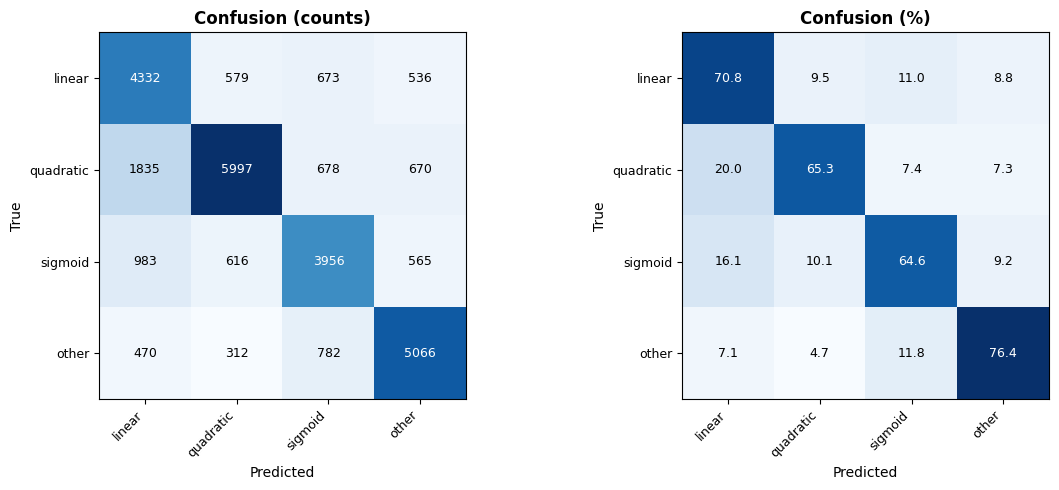

In [7]:
cm = confusion_matrix(labels_all, all_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title, fmt in [(axes[0], cm, 'Confusion (counts)', 'd'),
                             (axes[1], cm_pct, 'Confusion (%)', '.1f')]:
    im = ax.imshow(mat, cmap='Blues', interpolation='nearest')
    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            val = mat[i, j]
            color = 'white' if val > mat.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:{fmt}}', ha='center', va='center',
                    fontsize=9, color=color)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

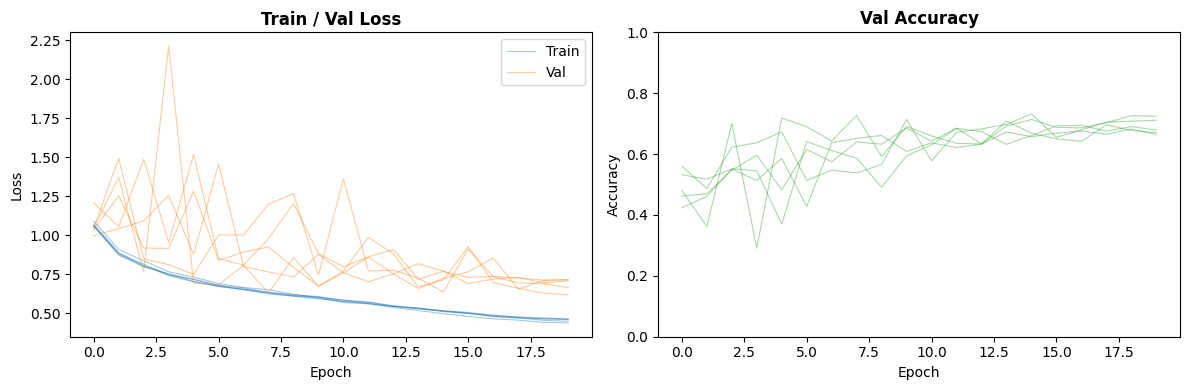

In [8]:
# Training curves (all folds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fold_i, h in enumerate(fold_histories):
    axes[0].plot(h['train_loss'], alpha=0.4, color='C0', linewidth=0.8)
    axes[0].plot(h['val_loss'], alpha=0.4, color='C1', linewidth=0.8)
    axes[1].plot(h['val_acc'], alpha=0.4, color='C2', linewidth=0.8)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Train / Val Loss', fontweight='bold')
axes[0].legend(['Train', 'Val'], loc='upper right')

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Val Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Accuracy vs SNR

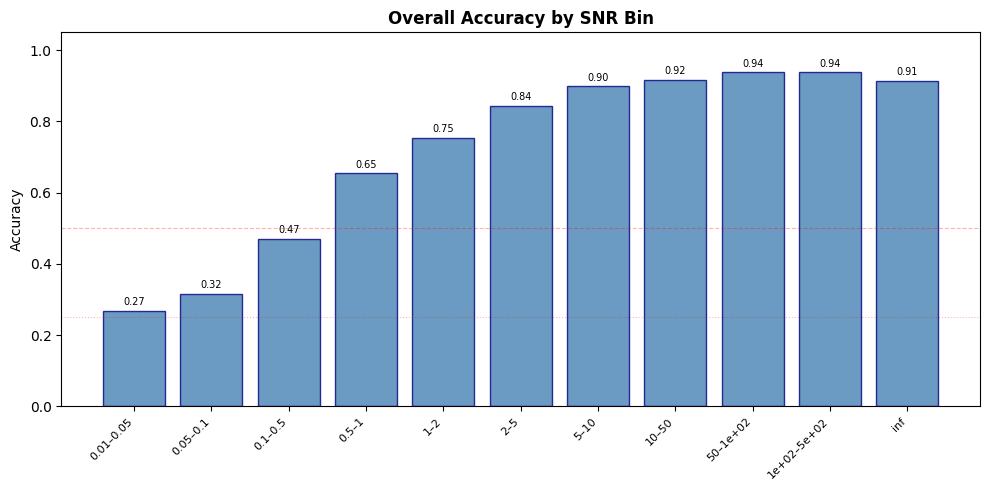

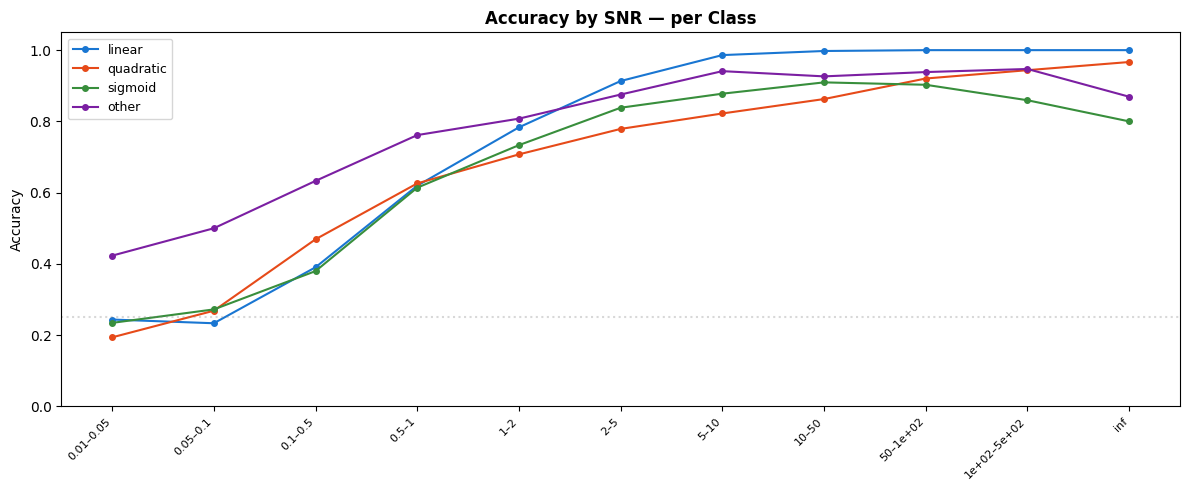

In [12]:
cases['pred'] = all_preds
cases['pred_name'] = cases['pred'].map({i: n for i, n in enumerate(CLASS_NAMES)})
cases['correct'] = (cases['label'] == cases['pred']).astype(int)

# Bin SNR into groups
finite_mask = np.isfinite(cases['snr_float'])
snr_bins = np.array([0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500])
snr_labels = [f'{a:.2g}–{b:.2g}' for a, b in zip(snr_bins[:-1], snr_bins[1:])]

snr_bin_series = pd.cut(
    cases.loc[finite_mask, 'snr_float'],
    bins=snr_bins, labels=snr_labels, include_lowest=True,
).astype(str)

cases['snr_bin'] = 'inf'
cases.loc[finite_mask, 'snr_bin'] = snr_bin_series

# Overall accuracy by SNR bin
snr_acc = cases.groupby('snr_bin')['correct'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
order = snr_labels + ['inf']
snr_acc = snr_acc.reindex(order)
bars = ax.bar(range(len(snr_acc)), snr_acc.values, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_xticks(range(len(snr_acc)))
ax.set_xticklabels(snr_acc.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Overall Accuracy by SNR Bin', fontweight='bold')
for i, v in enumerate(snr_acc.values):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
ax.axhline(0.25, color='red', linestyle=':', alpha=0.3, linewidth=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

# Per class
fig, ax = plt.subplots(figsize=(12, 5))
for cls_i, cls in enumerate(CLASS_NAMES):
    cls_data = cases[cases['class_name'] == cls]
    cls_snr_acc = cls_data.groupby('snr_bin')['correct'].mean().reindex(order)
    ax.plot(range(len(cls_snr_acc)), cls_snr_acc.values,
            marker='o', markersize=4, linewidth=1.5,
            color=CLASS_COLORS[cls], label=cls)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Accuracy by SNR — per Class', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0.25, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_vs_snr_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [13]:
errors = cases[cases['correct'] == 0].copy()
print(f'Total errors: {len(errors):,} / {len(cases):,} ({100*len(errors)/len(cases):.1f}%)')

# Top error pairs
error_pairs = errors.groupby(['class_name', 'pred_name']).size().reset_index(name='count')
error_pairs = error_pairs.sort_values('count', ascending=False).head(10)
print('\nTop error pairs (true → pred):')
for _, r in error_pairs.iterrows():
    print(f"  {r['class_name']:>12} → {r['pred_name']:<12} : {r['count']:>5}")

# Error rate by func_type
ft_err = cases.groupby('func_type').agg(
    n=('case_id', 'count'),
    errors=('correct', lambda x: (x == 0).sum()),
).reset_index()
ft_err['err_rate'] = ft_err['errors'] / ft_err['n'] * 100
ft_err = ft_err.sort_values('err_rate', ascending=False)
print('\nError rate by func_type:')
for _, r in ft_err.iterrows():
    print(f"  {r['func_type']:>16}: {r['err_rate']:>5.1f}%  ({r['errors']:>4} / {r['n']:>5})")

Total errors: 8,699 / 28,050 (31.0%)

Top error pairs (true → pred):
     quadratic → linear       :  1835
       sigmoid → linear       :   983
         other → sigmoid      :   782
     quadratic → sigmoid      :   678
        linear → sigmoid      :   673
     quadratic → other        :   670
       sigmoid → quadratic    :   616
        linear → quadratic    :   579
       sigmoid → other        :   565
        linear → other        :   536

Error rate by func_type:
           s_curve:  46.0%  (1409 /  3060)
      power_convex:  43.1%  (1318 /  3060)
     power_concave:  41.3%  (1264 /  3060)
            linear:  29.2%  (1788 /  6120)
         two_lines:  25.1%  ( 384 /  1530)
         threshold:  24.7%  ( 755 /  3060)
          parabola:  19.6%  ( 601 /  3060)
             spike:  17.9%  ( 548 /  3060)
        line_parab:  17.5%  ( 268 /  1530)


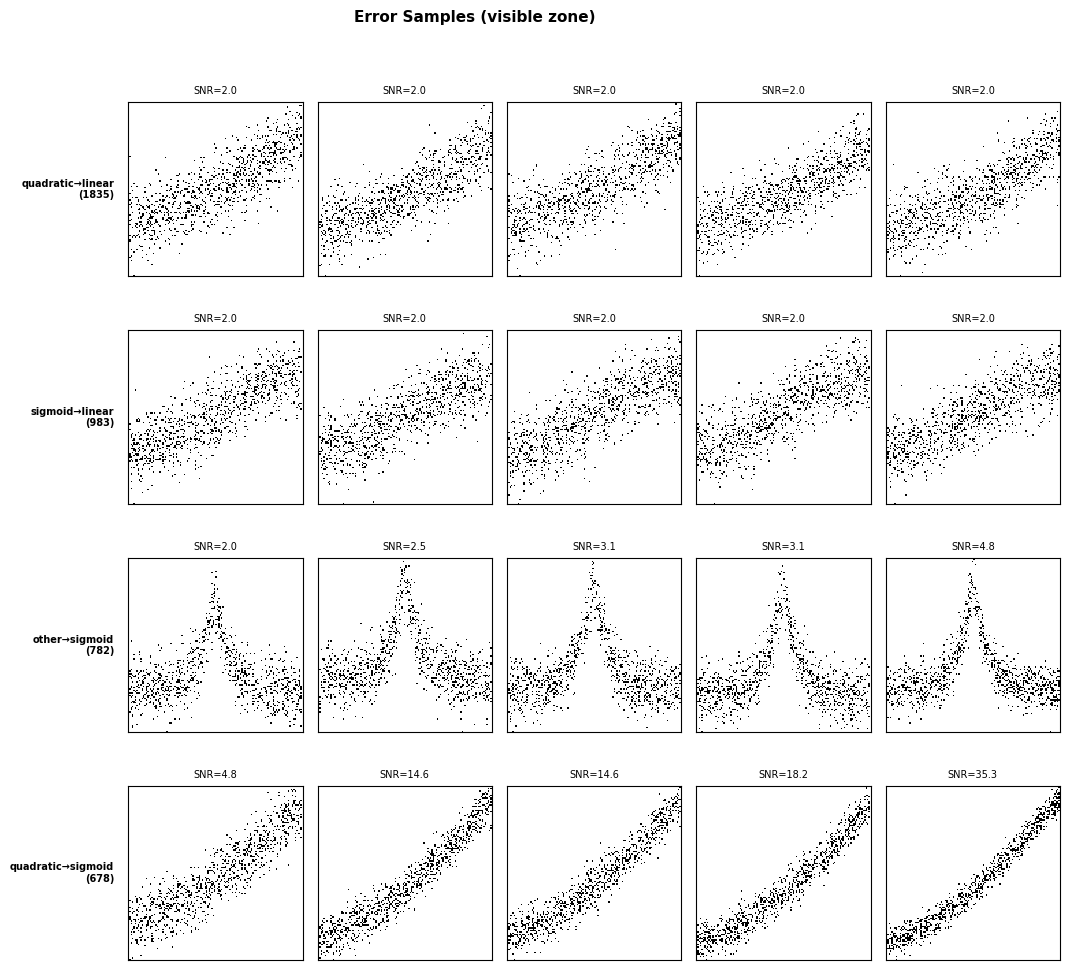

In [14]:
# Show example error images (top error pairs, visible zone only)
visible_errors = errors[errors.get('zone', 'visible') == 'visible'] if 'zone' in errors.columns else errors[errors['snr_float'] >= 2.0]

top_pairs = error_pairs.head(4)
n_show = min(4, len(top_pairs))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 5, figsize=(12, 2.5 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for row_i in range(n_show):
        pair = top_pairs.iloc[row_i]
        subset = visible_errors[
            (visible_errors['class_name'] == pair['class_name']) &
            (visible_errors['pred_name'] == pair['pred_name'])
        ]
        samples = subset.head(5)
        for col_i in range(5):
            ax = axes[row_i, col_i]
            if col_i < len(samples):
                idx = samples.index[col_i]
                ax.imshow(images[idx], cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
                snr_str = 'inf' if math.isinf(samples.iloc[col_i]['snr_float']) else f"{samples.iloc[col_i]['snr_float']:.1f}"
                ax.set_title(f"SNR={snr_str}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
        axes[row_i, 0].set_ylabel(
            f"{pair['class_name']}→{pair['pred_name']}\n({pair['count']})",
            fontsize=7, fontweight='bold', rotation=0, ha='right', va='center', labelpad=10
        )

    fig.suptitle('Error Samples (visible zone)', fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0.1, 0, 1, 0.96])
    plt.savefig(OUTPUT_DIR / 'error_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

## Accuracy by Zone

In [15]:
if 'zone' in cases.columns:
    zone_acc = cases.groupby(['zone', 'class_name'])['correct'].mean().unstack(fill_value=0)
    zone_acc = zone_acc.reindex(columns=CLASS_NAMES)
    zone_acc = zone_acc.reindex(['visible', 'fuzzy', 'invisible'])
    print('Accuracy by zone × class:')
    print(zone_acc.round(4))
    print()
    print('Overall by zone:')
    print(cases.groupby('zone')['correct'].mean().reindex(['visible', 'fuzzy', 'invisible']))
else:
    print('Zone info not available — run F_S1 with zone assignment first.')

Zone info not available — run F_S1 with zone assignment first.


## Summary

In [16]:
overall_acc = accuracy_score(labels_all, all_preds)
overall_bal = balanced_accuracy_score(labels_all, all_preds)
overall_f1 = f1_score(labels_all, all_preds, average='macro')

cls_str = ", ".join(CLASS_NAMES)
print('═' * 50)
print('F_S2 CNN Classification Summary')
print('═' * 50)
print(f'Total samples:     {len(cases):,}')
print(f'Classes:           {N_CLASSES} ({cls_str})')
print(f'Image size:        128×128 binary')
print(f'Model:             4-layer CNN ({n_params:,} params)')
print(f'Training:          {N_EPOCHS} epochs, Adam lr={LR}')
print(f'CV:                StratifiedGroupKFold({N_FOLDS})')
print(f'\nOverall accuracy:  {overall_acc:.4f}')
print(f'Balanced accuracy: {overall_bal:.4f}')
print(f'Macro F1:          {overall_f1:.4f}')
print(f'\nPer fold:')
for r in cv_results:
    print(f"  Fold {r['fold']}: acc={r['acc']:.4f}  bal_acc={r['bal_acc']:.4f}  f1={r['f1']:.4f}")

# Save predictions
cases.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/')

══════════════════════════════════════════════════
F_S2 CNN Classification Summary
══════════════════════════════════════════════════
Total samples:     28,050
Classes:           4 (linear, quadratic, sigmoid, other)
Image size:        128×128 binary
Model:             4-layer CNN (389,828 params)
Training:          20 epochs, Adam lr=0.001
CV:                StratifiedGroupKFold(5)

Overall accuracy:  0.6899
Balanced accuracy: 0.6929
Macro F1:          0.6875

Per fold:
  Fold 1: acc=0.6643  bal_acc=0.6732  f1=0.6664
  Fold 2: acc=0.6706  bal_acc=0.7039  f1=0.6713
  Fold 3: acc=0.7112  bal_acc=0.7149  f1=0.7083
  Fold 4: acc=0.7241  bal_acc=0.7289  f1=0.7145
  Fold 5: acc=0.6791  bal_acc=0.6635  f1=0.6549

Saved to output/S2/
